# SMT Data Challenge 2026 — EDA & Ideation

This notebook walks through each of the five datasets, explains what they represent,
describes every column, and documents data quality issues found during exploration.

## Dataset Overview

| Dataset | Type | Rows (approx) | Grain |
|---|---|---|---|
| `game-info.csv` | flat CSV | 251 | one row per game |
| `lineups.csv` | flat CSV | 76,961 | one row per pitch/play |
| `ball-events/` | partitioned CSV | 286,000 | one row per ball-tracking event |
| `ball-positions/` | partitioned CSV | 2,280,504 | one row per tracking frame (~50 ms) |
| `player-positions/` | partitioned CSV | very large | one row per player per tracking frame |

All partitioned datasets share the directory structure:
```
<dataset>/<home_team>/<away_team>/<year>/<day>/
```
The game identifier (`game_string`) encodes the same information as:
`y{year}_d{day}_{away_team}_{home_team}`

## Setup

In [1]:
import pandas as pd
import pyarrow.dataset as pads
import numpy as np
import matplotlib.pyplot as plt
import os

BASE = 'Data'

def load_partitioned(table_type, filter_expr=None, columns=None):
    """Load a partitioned dataset into a pandas DataFrame."""
    ds = pads.dataset(
        source=os.path.join(BASE, table_type),
        format='csv',
        partitioning=['home_team', 'away_team', 'year', 'day']
    )
    return ds.to_table(filter=filter_expr, columns=columns).to_pandas()

print('Base path:', os.path.abspath(BASE))

Base path: /Users/andrewzaletski/Desktop/VSCode/SMT-Data-Challenge-2026/Data


---
## 1. `game-info.csv`

**What it is:** The game manifest — one row for every game in the dataset.
It is the top-level key that ties all other datasets together via `game_string`.

### Column descriptions

| Column | Type | Description |
|---|---|---|
| `game_string` | string | Unique game identifier. Format: `y{year}_d{day}_{away}_{home}` |
| `year` | string | Season label. Only `y1` is present — a single anonymised season. |
| `game_date` | string | Day-of-season number, formatted `d{NNN}`. Ranges d061–d217. |
| `away_team_level` | int | Competition level of the away team. All values = 7 in this dataset. |
| `away_team` | string | Three-letter anonymised away team code. |
| `home_team_level` | int | Competition level of the home team. All values = 7. |
| `home_team` | string | Three-letter anonymised home team code. |

In [2]:
gi = pd.read_csv(os.path.join(BASE, 'game-info.csv'))
print('Shape:', gi.shape)
gi.head()

Shape: (251, 7)


,game_string,year,game_date,away_team_level,away_team,home_team_level,home_team
0,y1_d061_VKA_PHD,y1,d061,7,VKA,7,PHD
1,y1_d062_VKA_PHD,y1,d062,7,VKA,7,PHD
2,y1_d063_VKA_PHD,y1,d063,7,VKA,7,PHD
3,y1_d064_VKA_PHD,y1,d064,7,VKA,7,PHD
4,y1_d065_VAS_PHD,y1,d065,7,VAS,7,PHD


In [3]:
print('Unique game_strings:', gi['game_string'].nunique())
print('Unique teams:', sorted(set(gi['home_team'].tolist() + gi['away_team'].tolist())))
print('Team count:', len(set(gi['home_team'].tolist() + gi['away_team'].tolist())))
print('Team levels present:', gi['home_team_level'].unique())
print('Years present:', gi['year'].unique())

days = gi['game_date'].str.replace('d', '').astype(float)
print(f'Day-of-season range: {days.min():.0f} to {days.max():.0f}')
print('Null counts:')
print(gi.isnull().sum())

Unique game_strings: 250
Unique teams: ['ADQ', 'AIP', 'ALC', 'ANI', 'ARN', 'ATL', 'AVV', 'BKO', 'BTL', 'BXH', 'CYU', 'EMB', 'EXB', 'FET', 'FNQ', 'FSD', 'FXP', 'GJP', 'GNX', 'HNO', 'HYG', 'IGL', 'IOL', 'JGO', 'JJP', 'JPB', 'KTT', 'KVN', 'KZR', 'LRQ', 'MEX', 'MKS', 'MPC', 'MSE', 'MSN', 'MTW', 'NFP', 'NLG', 'NWM', 'NXS', 'NYN', 'OER', 'OSW', 'OWV', 'PHD', 'PWH', 'QBR', 'QHX', 'RME', 'RRM', 'RYU', 'SPL', 'SQF', 'SZJ', 'TDW', 'TES', 'THF', 'TQS', 'URD', 'VAS', 'VHA', 'VKA', 'VNG', 'WDF', 'WIF', 'WLI', 'WTH', 'XGM', 'XOZ', 'XPO', 'YXL', 'ZGC']
Team count: 72
Team levels present: [7]
Years present: ['y1']
Day-of-season range: 61 to 217
Null counts:
game_string        0
year               0
game_date          0
away_team_level    0
away_team          0
home_team_level    0
home_team          0
dtype: int64


In [4]:
# Games per team (home + away combined)
home_counts = gi['home_team'].value_counts()
away_counts = gi['away_team'].value_counts()
games_per_team = home_counts.add(away_counts, fill_value=0).sort_values(ascending=False)
print('Games per team (top 10):')
print(games_per_team.head(10))
print('\nGames per team (bottom 10):')
print(games_per_team.tail(10))

Games per team (top 10):
PHD    84.0
VAS    81.0
ARN    77.0
ANI    51.0
SZJ     5.0
OER     5.0
QHX     4.0
KZR     4.0
MEX     4.0
NWM     4.0
Name: count, dtype: float64

Games per team (bottom 10):
NYN    2.0
BKO    2.0
ALC    2.0
KVN    2.0
AVV    2.0
KTT    2.0
FSD    1.0
HNO    1.0
NLG    1.0
URD    1.0
Name: count, dtype: float64


### Data Quality — `game-info`

1. **Duplicate row:** `game-info.csv` has 251 rows but only 250 unique `game_string` values.
   The game `y1_d084_NXS_ARN` appears **twice** with identical values across all columns.

In [5]:
print('Duplicate rows in game-info:')
gi[gi.duplicated('game_string', keep=False)]

Duplicate rows in game-info:


,game_string,year,game_date,away_team_level,away_team,home_team_level,home_team
27,y1_d084_NXS_ARN,y1,d084,7,NXS,7,ARN
28,y1_d084_NXS_ARN,y1,d084,7,NXS,7,ARN


---
## 2. `lineups.csv`

**What it is:** The play-by-play lineup state for every pitch/play across all games.
Each row describes the defensive alignment and baserunner state **at the time of a specific
pitch or play**. This is the bridge that maps anonymous player IDs in the tracking data to
their fielding positions.

### Column descriptions

| Column | Type | Description |
|---|---|---|
| `game_string` | string | Foreign key to `game-info.game_string`. |
| `inning` | int | Inning number (1–13; extra innings are present). |
| `half_inning` | string | `"Top"` (away team batting) or `"Bottom"` (home team batting). |
| `home_team` | string | Home team code (redundant with `game_string`). |
| `away_team` | string | Away team code (redundant with `game_string`). |
| `at_bat` | int | Sequential at-bat number within the game. |
| `play_per_game` | int | Sequential pitch/play number within the game. Links to all tracking tables. |
| `is_pickoff` | bool | `True` if this play is a pickoff attempt rather than a regular pitch. |
| `pitcher` | string | Player ID of the pitcher (`TEAM-NNNN` format). |
| `catcher` | string | Player ID of the catcher. |
| `first_baseman` | string | Player ID at first base. |
| `second_baseman` | string | Player ID at second base. |
| `third_baseman` | string | Player ID at third base. |
| `shortstop` | string | Player ID at shortstop. |
| `left_fielder` | string | Player ID in left field. |
| `center_fielder` | string | Player ID in center field. |
| `right_fielder` | string | Player ID in right field. |
| `batter` | string | Player ID of the batter. Nullable (~74 rows). |
| `on_1b` | string | Player ID of runner on first base. `NaN` = base empty (~63% empty). |
| `on_2b` | string | Player ID of runner on second base. `NaN` = base empty (~80% empty). |
| `on_3b` | string | Player ID of runner on third base. `NaN` = base empty (~90% empty). |

**Note on player IDs:** All player IDs follow `TEAM-NNNN`. The team prefix on a fielder
ID is the **defensive team** (the team not currently batting).

In [6]:
lu = pd.read_csv(os.path.join(BASE, 'lineups.csv'))
print('Shape:', lu.shape)
lu.head()

Shape: (76961, 21)


,game_string,inning,half_inning,home_team,away_team,at_bat,play_per_game,is_pickoff,pitcher,catcher,...,second_baseman,third_baseman,shortstop,left_fielder,center_fielder,right_fielder,batter,on_1b,on_2b,on_3b
0,y1_d061_VKA_PHD,1,Top,PHD,VKA,1,1,False,PHD-4341,PHD-5504,...,PHD-7743,PHD-6069,PHD-0812,PHD-7166,PHD-8619,PHD-5994,VKA-5565,NaN,NaN,NaN
1,y1_d061_VKA_PHD,1,Top,PHD,VKA,1,2,False,PHD-4341,PHD-5504,...,PHD-7743,PHD-6069,PHD-0812,PHD-7166,PHD-8619,PHD-5994,VKA-5565,NaN,NaN,NaN
2,y1_d061_VKA_PHD,1,Top,PHD,VKA,2,3,False,PHD-4341,PHD-5504,...,PHD-7743,PHD-6069,PHD-0812,PHD-7166,PHD-8619,PHD-5994,VKA-7844,NaN,NaN,NaN
3,y1_d061_VKA_PHD,1,Top,PHD,VKA,3,4,False,PHD-4341,PHD-5504,...,PHD-7743,PHD-6069,PHD-0812,PHD-7166,PHD-8619,PHD-5994,VKA-7206,NaN,NaN,NaN
4,y1_d061_VKA_PHD,1,Top,PHD,VKA,3,5,False,PHD-4341,PHD-5504,...,PHD-7743,PHD-6069,PHD-0812,PHD-7166,PHD-8619,PHD-5994,VKA-7206,NaN,NaN,NaN


In [7]:
print('Null counts:')
print(lu.isnull().sum())
print()
print('half_inning values:', lu['half_inning'].unique())
print('Inning range:', lu['inning'].min(), 'to', lu['inning'].max())
print('Extra-inning distribution:')
print(lu[lu['inning'] > 9]['inning'].value_counts().sort_index())
print()
print('is_pickoff True count:', lu['is_pickoff'].sum())
print('Null batter count:', lu['batter'].isnull().sum())

Null counts:
game_string           0
inning                0
half_inning           0
home_team             0
away_team             0
at_bat                0
play_per_game         0
is_pickoff            0
pitcher               0
catcher               0
first_baseman         0
second_baseman        0
third_baseman         0
shortstop             0
left_fielder          0
center_fielder        0
right_fielder         0
batter               74
on_1b             48764
on_2b             61824
on_3b             69051
dtype: int64

half_inning values: ['Top' 'Bottom']
Inning range: 1 to 13
Extra-inning distribution:
inning
10    427
11    148
12     87
13     55
Name: count, dtype: int64

is_pickoff True count: 1676
Null batter count: 74


In [8]:
print('Base occupancy rates:')
print(f'  1B occupied: {lu["on_1b"].notna().mean()*100:.1f}%')
print(f'  2B occupied: {lu["on_2b"].notna().mean()*100:.1f}%')
print(f'  3B occupied: {lu["on_3b"].notna().mean()*100:.1f}%')
print()
print('Unique games in lineups:', lu['game_string'].nunique())
print('Plays per game (stats):')
print(lu.groupby('game_string')['play_per_game'].max().describe())

Base occupancy rates:
  1B occupied: 36.6%
  2B occupied: 19.7%
  3B occupied: 10.3%

Unique games in lineups: 250
Plays per game (stats):
count    250.000000
mean     306.768000
std       45.801323
min      135.000000
25%      281.250000
50%      308.000000
75%      336.750000
max      446.000000
Name: play_per_game, dtype: float64


### Data Quality — `lineups`

1. **74 null `batter` values:** Rows have valid fielding lineups and base states but no batter.
   Scattered across many games — likely a data capture gap.

2. **341 `play_per_game` values with multiple rows:** Some play IDs map to 2–4 rows. This can
   reflect legitimate state changes mid-sequence (e.g., runner scores during play) but must
   be accounted for when joining to tracking data.

3. **Extra innings up to 13:** Not a quality issue, but affects assumptions about game length.

In [9]:
print('Sample null-batter rows:')
lu[lu['batter'].isnull()][
    ['game_string','inning','half_inning','at_bat','play_per_game','batter','on_1b','on_2b','on_3b']
].head(8)

Sample null-batter rows:


,game_string,inning,half_inning,at_bat,play_per_game,batter,on_1b,on_2b,on_3b
136,y1_d061_VKA_PHD,6,Top,41,137,NaN,VKA-5565,VKA-3145,NaN
765,y1_d063_VKA_PHD,8,Top,59,218,NaN,NaN,NaN,NaN
1997,y1_d068_SQF_ARN,6,Bottom,62,272,NaN,NaN,NaN,NaN
2868,y1_d071_SQF_ARN,8,Top,69,263,NaN,NaN,NaN,NaN
4619,y1_d074.5_AIP_ARN,3,Top,22,95,NaN,AIP-5897,AIP-3946,NaN
5181,y1_d077_PHD_VAS,4,Top,26,110,NaN,NaN,NaN,PHD-7743
5210,y1_d077_PHD_VAS,4,Bottom,32,139,NaN,VAS-5184,NaN,NaN
5276,y1_d077_PHD_VAS,6,Top,52,206,NaN,NaN,NaN,NaN


In [10]:
play_row_counts = lu.groupby(['game_string','play_per_game']).size()
print('Distribution of rows per play:')
print(play_row_counts.value_counts().sort_index())

Distribution of rows per play:
1    75773
2       88
4      253
Name: count, dtype: int64


---
## 3. `ball-events/` (partitioned)

**What it is:** A log of discrete tracking events associated with the ball during each play.
Each row represents a moment where a meaningful state change was detected (e.g., ball released
by pitcher, ball caught, ball hits the ground). Think of these as the "chapter markers" within
the continuous ball trajectory recorded in `ball-positions`.

**Partitioning:** `home_team / away_team / year / day`

### Column descriptions

| Column | Type | Description |
|---|---|---|
| `game_string` | string | Game identifier. |
| `play_per_game` | float | Play sequence number (matches `lineups.play_per_game`). Nullable. |
| `timestamp` | float | Milliseconds elapsed within the game at the moment of the event. |
| `player_id` | int | Positional player slot involved in the event (see table below). |
| `ball_eventcode` | int | Integer code for the type of ball event (see table below). |

#### `player_id` encoding

| `player_id` | Meaning |
|---|---|
| 0 | System / ball sentinel — always paired with `ball_eventcode = 5` |
| 1–9 | Home team players (positional slots, not unique player IDs) |
| 10–18 | Away team players (same positional mapping, offset by 9) |
| 19 | Likely batter or substitute slot |
| 255 | System / umpire sentinel — used for out-calls and score events |

#### `ball_eventcode` values and observed counts

| Code | Count | Likely meaning |
|---|---|---|
| 1 | 74,166 | Ball released — pitch start |
| 2 | 70,907 | Ball received — pitch end (caught by catcher or first field touch) |
| 3 | 9,336 | Ball becomes live / put in play |
| 4 | 25,454 | Ball fielded / caught in the field |
| 5 | 75,787 | Ball state update — system event, always `player_id = 0` |
| 6 | 1,620 | Ball hits the ground |
| 7 | 131 | Rare — possibly foul tip or off-bat contact |
| 8 | 13 | Very rare — possible tracking anomaly or special play |
| 9 | 1,361 | Out recorded |
| 10 | 987 | Run / score recorded |
| 11 | 658 | Additional out/score sub-type |
| 16 | 25,580 | Play end / reset — always `player_id = 255` |

In [11]:
# Load all ball-events (286k rows — manageable)
be = load_partitioned('ball-events')
print('Shape:', be.shape)
be.head()

Shape: (286000, 9)


,game_string,play_per_game,timestamp,player_id,ball_eventcode,home_team,away_team,year,day
0,y1_d143_ADQ_ANI,1.0,50804.0,1,1,ANI,ADQ,y1,d143
1,y1_d143_ADQ_ANI,1.0,51254.0,2,2,ANI,ADQ,y1,d143
2,y1_d143_ADQ_ANI,1.0,51254.0,0,5,ANI,ADQ,y1,d143
3,y1_d143_ADQ_ANI,2.0,68204.0,1,1,ANI,ADQ,y1,d143
4,y1_d143_ADQ_ANI,2.0,68654.0,2,2,ANI,ADQ,y1,d143


In [12]:
print('ball_eventcode distribution:')
print(be['ball_eventcode'].value_counts().sort_index())
print()
print('player_id distribution:')
print(be['player_id'].value_counts().sort_index())

ball_eventcode distribution:
ball_eventcode
1     74166
2     70907
3      9336
4     25454
5     75787
6      1620
7       131
8        13
9      1361
10      987
11      658
16    25580
Name: count, dtype: int64

player_id distribution:
player_id
0      75787
1      76905
2      49709
3       6374
4       5494
5       2782
6       5414
7       3386
8       3663
9       3537
10     25693
11         9
12         4
14         2
15         2
19         2
255    27237
Name: count, dtype: int64


In [13]:
print('player_id=0 event codes:', be[be['player_id']==0]['ball_eventcode'].value_counts().to_dict())
print('player_id=255 event codes:', be[be['player_id']==255]['ball_eventcode'].value_counts().to_dict())
print()
print('Timestamp range:', be['timestamp'].min(), 'to', be['timestamp'].max(), 'ms')
print('play_per_game range:', be['play_per_game'].min(), 'to', be['play_per_game'].max())
print('play_per_game null count:', be['play_per_game'].isnull().sum())

player_id=0 event codes: {5: 75787}
player_id=255 event codes: {16: 25580, 10: 987, 11: 658, 9: 12}

Timestamp range: 147.0 to 75402063.0 ms
play_per_game range: 0.0 to 446.0
play_per_game null count: 2253


In [14]:
# Typical event sequence for a single play
sample_play = be[
    (be['game_string'] == 'y1_d143_ADQ_ANI') & (be['play_per_game'] == 1)
].sort_values('timestamp')
print('Event sequence for play 1 of y1_d143_ADQ_ANI:')
sample_play[['timestamp','player_id','ball_eventcode']]

Event sequence for play 1 of y1_d143_ADQ_ANI:


,timestamp,player_id,ball_eventcode
0,50804.0,1,1
1,51254.0,2,2
2,51254.0,0,5


### Data Quality — `ball-events`

1. **2,253 rows with `game_string = 'NA'` and null `play_per_game` / `timestamp`.**
   These have valid `ball_eventcode` and `player_id` but no game context — corrupt records.
   Filter with `game_string != 'NA'` before analysis.

2. **Event codes 7 (131 rows) and 8 (13 rows) are extremely rare** and their meaning is
   not documented. Treat with caution until confirmed.

3. **`play_per_game = 0` in 10 rows.** Plays should be 1-indexed; these may be
   pre-game or off-by-one logging artifacts.

In [15]:
print('Corrupt rows (game_string=NA):', (be['game_string']=='NA').sum())
print('Sample:')
be[be['game_string']=='NA'].head(5)

Corrupt rows (game_string=NA): 2253
Sample:


,game_string,play_per_game,timestamp,player_id,ball_eventcode,home_team,away_team,year,day
1611,NA,NaN,NaN,1,1,ANI,ADQ,y1,d144
1612,NA,NaN,NaN,10,4,ANI,ADQ,y1,d144
1613,NA,NaN,NaN,0,5,ANI,ADQ,y1,d144
1614,NA,NaN,NaN,1,1,ANI,ADQ,y1,d144
1615,NA,NaN,NaN,2,2,ANI,ADQ,y1,d144


In [16]:
print('play_per_game = 0:')
be[be['play_per_game']==0][['game_string','play_per_game','timestamp','player_id','ball_eventcode']].head()

play_per_game = 0:


,game_string,play_per_game,timestamp,player_id,ball_eventcode
244012,y1_d104_MSN_VAS,0.0,96586.0,1,1
244013,y1_d104_MSN_VAS,0.0,97136.0,2,2
244014,y1_d104_MSN_VAS,0.0,97136.0,0,5
244100,y1_d104_MSN_VAS,0.0,958504.0,1,1
244101,y1_d104_MSN_VAS,0.0,959004.0,10,4


---
## 4. `ball-positions/` (partitioned)

**What it is:** High-frequency ball tracking — the 3D position of the ball sampled at
approximately **20 Hz (every 50 ms)**. This is the most granular dataset (2.28M rows) and
captures full ball trajectories: pitches, batted balls, throws, and ball-in-hand moments.

**Partitioning:** `home_team / away_team / year / day`

### Column descriptions

| Column | Type | Description |
|---|---|---|
| `game_string` | string | Game identifier. |
| `play_per_game` | float | Play sequence number. Nullable (see data quality). |
| `timestamp` | float | Milliseconds within the game. Aligns with `ball-events.timestamp`. |
| `ball_position_x` | float | Horizontal position in feet. 0 ≈ center of home plate. Left = negative. |
| `ball_position_y` | float | Depth in feet from home plate toward the outfield. Home plate ≈ 0. |
| `ball_position_z` | float | Height in feet above the playing surface. Ground = 0. |

#### Coordinate system (inferred)

- **Origin:** approximately at home plate
- **X:** horizontal / left–right. Left field = negative, right field = positive
- **Y:** along the foul line toward the outfield. Home plate ≈ 0, second base ≈ 127 ft, deep outfield > 300 ft
- **Z:** vertical height. Ground = 0, typical pitch height ≈ 2–4 ft, high fly ball > 100 ft

#### Full-dataset coordinate ranges (2.28M rows)

| Axis | Min | Max | Mean |
|---|---|---|---|
| X | −349 ft | +297 ft | 0.6 ft |
| Y | −58 ft | +868 ft | 100 ft |
| Z | −9 ft | +440 ft | 21 ft |

In [17]:
# Load one team's games as a representative sample
bp_sample = load_partitioned(
    'ball-positions',
    filter_expr=pads.field('home_team') == 'PHD'
)
print('Sample shape (PHD home games):', bp_sample.shape)
bp_sample.head()

Sample shape (PHD home games): (626179, 10)


,game_string,play_per_game,timestamp,ball_position_x,ball_position_y,ball_position_z,home_team,away_team,year,day
0,y1_d195_ARN_PHD,1.0,18943.0,1.895703,52.89720,6.12273,PHD,ARN,y1,d195
1,y1_d195_ARN_PHD,1.0,18993.0,1.582401,46.32450,5.96580,PHD,ARN,y1,d195
2,y1_d195_ARN_PHD,1.0,19043.0,1.282767,39.81000,5.77659,PHD,ARN,y1,d195
3,y1_d195_ARN_PHD,1.0,19093.0,0.996801,33.35370,5.55519,PHD,ARN,y1,d195
4,y1_d195_ARN_PHD,1.0,19143.0,0.724506,26.95587,5.30151,PHD,ARN,y1,d195


In [18]:
print('XYZ summary statistics (sample):')
bp_sample[['ball_position_x','ball_position_y','ball_position_z']].describe()

XYZ summary statistics (sample):


,ball_position_x,ball_position_y,ball_position_z
count,626179.000000,626179.000000,626179.000000
mean,-0.516660,100.235860,22.014001
std,57.260659,92.970584,38.735118
min,-348.855000,-29.954700,-8.961810
25%,-8.890785,27.140775,2.911701
50%,-0.303339,60.893100,5.413080
75%,13.171875,164.890050,16.730475
max,270.471300,480.483000,382.191000


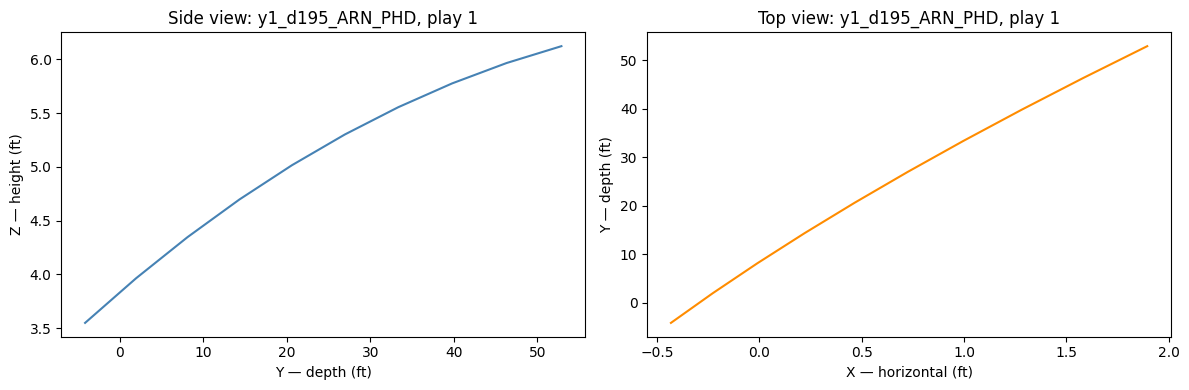

In [19]:
# Visualise a single pitch trajectory
first_game = bp_sample['game_string'].iloc[0]
one_play = bp_sample[
    (bp_sample['game_string'] == first_game) & (bp_sample['play_per_game'] == 1)
].sort_values('timestamp')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(one_play['ball_position_y'], one_play['ball_position_z'], color='steelblue')
axes[0].set_xlabel('Y — depth (ft)')
axes[0].set_ylabel('Z — height (ft)')
axes[0].set_title(f'Side view: {first_game}, play 1')

axes[1].plot(one_play['ball_position_x'], one_play['ball_position_y'], color='darkorange')
axes[1].set_xlabel('X — horizontal (ft)')
axes[1].set_ylabel('Y — depth (ft)')
axes[1].set_title(f'Top view: {first_game}, play 1')

plt.tight_layout()
plt.show()

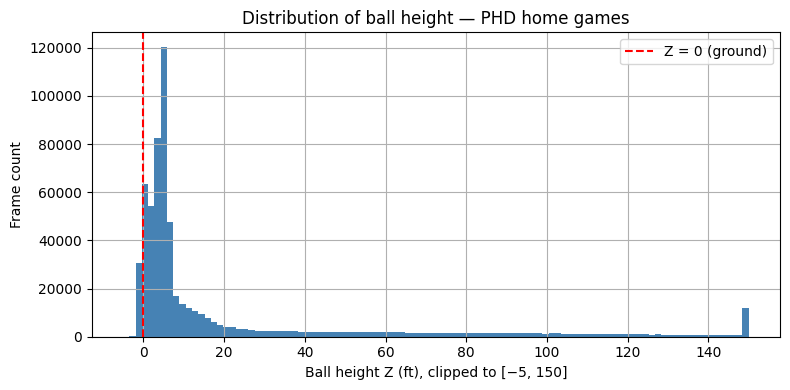

In [20]:
# Distribution of Z height in sample
fig, ax = plt.subplots(figsize=(8, 4))
bp_sample['ball_position_z'].clip(-5, 150).hist(bins=100, ax=ax, color='steelblue', edgecolor='none')
ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Z = 0 (ground)')
ax.set_xlabel('Ball height Z (ft), clipped to [−5, 150]')
ax.set_ylabel('Frame count')
ax.set_title('Distribution of ball height — PHD home games')
ax.legend()
plt.tight_layout()
plt.show()

### Data Quality — `ball-positions`

1. **17,236 rows with `game_string = 'NA'` and null `play_per_game` / `timestamp`.**
   Same class of corrupt records as in `ball-events`. Filter before analysis.

2. **170,249 rows with Z < 0 (ball below ground).** Small negative values (> −0.5 ft) are
   tracking noise when the ball is on the ground. The 16,502 rows with Z < −1 are more
   anomalous and likely indicate miscalibration.

3. **Z up to 440 ft.** Physically impossible — the highest recorded fly ball barely exceeds
   200 ft. Values > 200 ft are tracker failures.

4. **Y up to 868 ft.** Standard outfield walls are 300–400 ft. Extreme Y values (> 550 ft)
   are likely tracker artifacts.

In [21]:
# Full-dataset quality summary (pre-computed)
print('Full dataset (2.28M rows) data quality summary:')
print(f'  Null play_per_game (game_string=NA):  17,236 rows')
print(f'  Z < 0 (tracking noise at ground):   170,249 rows')
print(f'  Z < -1 (probable errors):            16,502 rows')
print()
# Show in sample
print('Negative Z rows in sample:')
bp_sample[bp_sample['ball_position_z'] < 0][
    ['game_string','play_per_game','timestamp','ball_position_x','ball_position_y','ball_position_z']
].head(5)

Full dataset (2.28M rows) data quality summary:
  Null play_per_game (game_string=NA):  17,236 rows
  Z < 0 (tracking noise at ground):   170,249 rows
  Z < -1 (probable errors):            16,502 rows

Negative Z rows in sample:


,game_string,play_per_game,timestamp,ball_position_x,ball_position_y,ball_position_z
249,y1_d195_ARN_PHD,9.0,225693.0,-40.037700,44.52570,-0.065716
262,y1_d195_ARN_PHD,9.0,226343.0,-61.557600,70.20930,-0.011477
336,y1_d195_ARN_PHD,13.0,441893.0,1.724727,-4.46295,-0.248781
541,y1_d195_ARN_PHD,21.0,597993.0,1.541865,-5.87199,-0.215365
630,y1_d195_ARN_PHD,23.0,633143.0,137.132100,196.03410,-0.643092


---
## 5. `player-positions/` (partitioned)

**What it is:** High-frequency player tracking — the 2D position of every player on the
field at approximately **20 Hz (every 50 ms)**. This is the largest dataset by volume.
Multiple rows per timestamp (one per player), so each timestamp has ~18 rows (9 per team).

**Partitioning:** `home_team / away_team / year / day`

**Note:** Only 2D position is available for players — there is no Z/height column.

### Column descriptions

| Column | Type | Description |
|---|---|---|
| `game_string` | string | Game identifier. |
| `play_per_game` | float | Play sequence number. Aligns with `ball-positions` timestamps. |
| `timestamp` | float | Milliseconds within the game. Same grid as `ball-positions`. |
| `player_id` | int | Positional slot (1–19). Same encoding as `ball-events.player_id`. |
| `field_x` | float | Horizontal position in feet (same X axis as `ball-positions`). |
| `field_y` | float | Depth in feet from home plate (same Y axis as `ball-positions`). |

#### Resolving `player_id` to a named player

Join `player-positions` to `lineups` on `(game_string, play_per_game)`.
Player slots map to lineup columns as follows (home team convention):

| Slot | Fielding position |
|---|---|
| 1 | Pitcher |
| 2 | Catcher |
| 3 | First baseman |
| 4 | Second baseman |
| 5 | Third baseman |
| 6 | Shortstop |
| 7 | Left fielder |
| 8 | Center fielder |
| 9 | Right fielder |
| 10–18 | Away team (same offsets) |
| 15, 17–19 | Baserunners or substitute slots |

In [22]:
# Load sample (full dataset is very large)
pp_sample = load_partitioned(
    'player-positions',
    filter_expr=pads.field('home_team') == 'PHD'
)
print('Sample shape (PHD home games):', pp_sample.shape)
pp_sample.head()

Sample shape (PHD home games): (19408763, 10)


,game_string,play_per_game,timestamp,player_id,field_x,field_y,home_team,away_team,year,day
0,y1_d195_ARN_PHD,1.0,18943.0,1,0.4545,56.6895,PHD,ARN,y1,d195
1,y1_d195_ARN_PHD,1.0,18943.0,2,-1.1301,-4.4676,PHD,ARN,y1,d195
2,y1_d195_ARN_PHD,1.0,18943.0,3,49.3263,77.7429,PHD,ARN,y1,d195
3,y1_d195_ARN_PHD,1.0,18943.0,4,38.2419,146.4168,PHD,ARN,y1,d195
4,y1_d195_ARN_PHD,1.0,18943.0,5,-54.9726,77.0277,PHD,ARN,y1,d195


In [23]:
print('player_id values observed:', sorted(pp_sample['player_id'].unique()))
print()
print('Field position summary:')
print(pp_sample[['field_x','field_y']].describe())
print()
print('Null counts:', pp_sample.isnull().sum().to_dict())

player_id values observed: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19)]

Field position summary:
            field_x       field_y
count  1.940876e+07  1.940876e+07
mean   1.617510e+00  1.224801e+02
std    6.909621e+01  9.799166e+01
min   -2.399628e+02 -3.123810e+01
25%   -4.670100e+01  5.953590e+01
50%   -6.750000e-02  9.312540e+01
75%    5.391060e+01  1.524387e+02
max    2.345694e+02  4.011894e+02

Null counts: {'game_string': 0, 'play_per_game': 94702, 'timestamp': 94702, 'player_id': 0, 'field_x': 0, 'field_y': 0, 'home_team': 0, 'away_team': 0, 'year': 0, 'day': 0}


In [24]:
# How many players are tracked per timestamp?
players_per_ts = pp_sample.groupby(['game_string','play_per_game','timestamp'])['player_id'].count()
print('Players tracked per frame:')
print(players_per_ts.value_counts().sort_index())

Players tracked per frame:
player_id
1       4827
2        400
3         79
4         56
5         97
6         45
7         40
8         48
9        418
10     57403
11    158328
12    284349
13    377956
14    296314
15    177114
16     89925
17     22055
18      2333
19        37
Name: count, dtype: int64


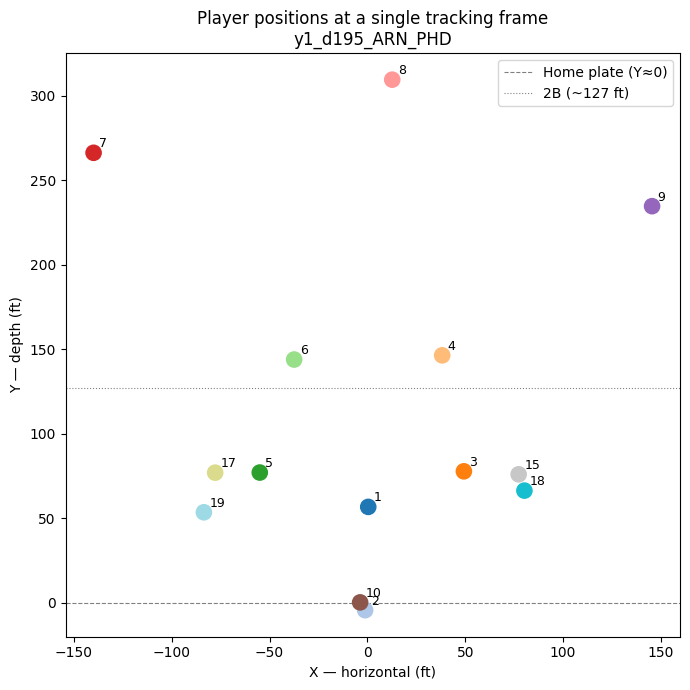

In [25]:
# Field layout snapshot — all players at a single frame
first_ts = pp_sample[(pp_sample['play_per_game']==1) & 
                     (pp_sample['game_string']==pp_sample['game_string'].iloc[0])]['timestamp'].min()
snapshot = pp_sample[pp_sample['timestamp']==first_ts]

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(snapshot['field_x'], snapshot['field_y'],
           c=snapshot['player_id'], cmap='tab20', s=120, zorder=3)
for _, row in snapshot.iterrows():
    ax.annotate(int(row['player_id']), (row['field_x'], row['field_y']),
                textcoords='offset points', xytext=(4, 4), fontsize=9)

ax.axhline(0, color='gray', linestyle='--', linewidth=0.8, label='Home plate (Y≈0)')
ax.axhline(127.3, color='gray', linestyle=':', linewidth=0.8, label='2B (~127 ft)')
ax.set_xlabel('X — horizontal (ft)')
ax.set_ylabel('Y — depth (ft)')
ax.set_title(f'Player positions at a single tracking frame\n{snapshot["game_string"].iloc[0]}')
ax.legend()
plt.tight_layout()
plt.show()

### Data Quality — `player-positions`

1. **Occasional frames with fewer than 18 players.** Some frames show 14–17 players,
   indicating tracking dropouts. Analyses requiring all fielders should filter to
   frames where `player_count == 18` (or expected count for the game state).

2. **No Z column.** Player height is not tracked. 3D player analyses are not possible.

3. **Negative `field_y` is expected.** The catcher routinely appears behind home plate
   (Y ≈ −5 ft). Values below −10 ft are unusual.

---
## 6. Dataset Relationships

```
game-info
  └─ game_string ─────────────────────────────────────────────────────┐
                                                                        │
lineups                                                                 │
  └─ game_string + play_per_game  → identifies each pitch/play context │
  └─ pitcher / catcher / fielders → named player IDs (TEAM-NNNN)      │
                                                                        │
ball-events (partitioned)                                               │
  └─ game_string + play_per_game + timestamp                           │
  └─ player_id (slot 1–18) → join to lineups to get player name ───────┘

ball-positions (partitioned)
  └─ game_string + play_per_game + timestamp  ← align by timestamp
                                               with ball-events
player-positions (partitioned)
  └─ game_string + play_per_game + timestamp  ← same 50ms frame grid
  └─ player_id (slot 1–18)                   ← same slots as ball-events
```

### Key join patterns

- **Named fielder for a tracking frame:** `player-positions` → `lineups` on `(game_string, play_per_game)`, then map `player_id` slot to the appropriate fielding-position column.
- **Ball position at a specific event:** `ball-events` → `ball-positions` on `(game_string, play_per_game, timestamp)`.
- **Efficient loading:** Always filter by partition columns (`home_team`, `away_team`, `year`, `day`) to avoid reading the full dataset into memory.

In [26]:
# Cross-dataset integrity: games in lineups vs game-info
lu = pd.read_csv(os.path.join(BASE, 'lineups.csv'))
gi = pd.read_csv(os.path.join(BASE, 'game-info.csv'))

in_lu = set(lu['game_string'].unique())
in_gi = set(gi['game_string'].unique())

print(f'Unique games in lineups:   {len(in_lu)}')
print(f'Unique games in game-info: {len(in_gi)}')
print(f'In lineups but not game-info: {in_lu - in_gi}')
print(f'In game-info but not lineups: {in_gi - in_lu}')
print('\nConclusion: perfect 1-1 match between game-info and lineups.')

Unique games in lineups:   250
Unique games in game-info: 250
In lineups but not game-info: set()
In game-info but not lineups: set()

Conclusion: perfect 1-1 match between game-info and lineups.


---
## 7. Summary of Data Quality Issues

| Dataset | Issue | Affected rows | Recommended handling |
|---|---|---|---|
| `game-info` | Duplicate row: `y1_d084_NXS_ARN` | 1 extra | `drop_duplicates('game_string')` |
| `lineups` | Null `batter` field | 74 | Exclude from batter-dependent analyses |
| `lineups` | Multiple rows per `play_per_game` | 341 plays | Deduplicate or take first row per play |
| `ball-events` | `game_string = 'NA'`, null timestamp | 2,253 | Filter `game_string != 'NA'` |
| `ball-events` | `play_per_game = 0` | 10 | Exclude (likely off-by-one / pre-game) |
| `ball-events` | Rare event codes 7 and 8 | 144 total | Use with caution; meaning unclear |
| `ball-positions` | `game_string = 'NA'`, null timestamp | 17,236 | Filter `game_string != 'NA'` |
| `ball-positions` | Negative Z (tracking noise at ground) | 170,249 | Clip to 0 or filter Z ≥ −0.5 |
| `ball-positions` | Z < −1 ft (probable calibration error) | 16,502 | Filter Z > −1 |
| `ball-positions` | Z > 200 ft (physically impossible) | small | Filter out |
| `ball-positions` | Y > 550 ft (likely tracker artifact) | small | Inspect and filter |